### Matthew Riddell 
### D00245674
### MSc in Data Analytics
### Dissertation
### Log Linear Regression Jupyter Notebook

Log Tranformed Linear Regression models

In this file I conduct feature selection and modelling to answer each of the main research questions

For each question I create three Log Transformed Linear Regression models:

#### Research Question 2:

Can socio-economic indicators explain participation rates?

Log Linear Regressions Models:

- 2A
- 2B
- 2C

#### Research Question 3:

Can socio-economic indicators explain participation rates when the analysis is reduced to only successful Petitions?

Log Linear Regressions Models:

- 3A
- 3B
- 3C

Each model performance is evaluated using OLS regression results

Specifically R Squared 

And model P values

Finally Each model is exported using Joblib


### Link to each Dataset:

### ECI Petitions:
#### 2024

- ECI 01: https://citizens-initiative.europa.eu/initiatives/details/2024/000001_en Ban on conversion practices in the European Union
- ECI 02: https://citizens-initiative.europa.eu/initiatives/details/2024/000002_en European Citizens' Initiative in Defence of Agriculture and Rural Economy in Europe
- ECI 03: https://citizens-initiative.europa.eu/initiatives/details/2024/000004_en My Voice, My Choice: For Safe And Accessible Abortion
- ECI 04: https://citizens-initiative.europa.eu/initiatives/details/2024/000006_en Air-Quotas
- ECI 05: https://citizens-initiative.europa.eu/initiatives/details/2024/000007_en Stop Destroying Videogames
- ECI 06: https://citizens-initiative.europa.eu/initiatives/details/2024/000008_en Stop Cruelty Stop Slaughter
- ECI 07: https://citizens-initiative.europa.eu/initiatives/details/2024/000009_en STOP FAKE FOOD: ORIGIN ON LABEL
- ECI 08: https://citizens-initiative.europa.eu/initiatives/details/2024/000010_en ECI for a Water-Smart and Resilient Europe
- ECI 09: https://citizens-initiative.europa.eu/initiatives/details/2024/000011_en PsychedeliCare

#### 2023

- ECI 10: https://citizens-initiative.europa.eu/initiatives/details/2023/000001_en Stop torture and inhuman treatment at Europe’s borders
- ECI 11: https://citizens-initiative.europa.eu/initiatives/details/2023/000002_en Ensuring a dignified reception of migrants in Europe
- ECI 12: https://citizens-initiative.europa.eu/initiatives/details/2023/000003_en End The Horse Slaughter Age
- ECI 13: https://citizens-initiative.europa.eu/initiatives/details/2023/000004_en Connecting all European capitals and people through a high-speed train network
- ECI 14: https://citizens-initiative.europa.eu/initiatives/details/2023/000005_en Effective implementation of the concept of judicial precedent in EU countries
- ECI 15: https://citizens-initiative.europa.eu/initiatives/details/2023/000006_en Taxing great wealth to finance the ecological and social transition
- ECI 16: https://citizens-initiative.europa.eu/initiatives/details/2023/000007_en Preservation and development of Ukrainian culture, education, language, and traditions in EU states
- ECI 17: https://citizens-initiative.europa.eu/initiatives/details/2023/000008_en EU Live Bus Stop Info
- ECI 18: https://citizens-initiative.europa.eu/initiatives/details/2023/000009_en Trust and Freedom
- ECI 19: https://citizens-initiative.europa.eu/initiatives/details/2023/000011_en Creation of a European Environment Authority

#### 2022

- ECI 20: https://citizens-initiative.europa.eu/initiatives/details/2022/000001_en Win It On The Pitch 
- ECI 21: https://citizens-initiative.europa.eu/initiatives/details/2022/000002_en Fur Free Europe
- ECI 22: https://citizens-initiative.europa.eu/initiatives/details/2022/000003_en End The Slaughter Age
- ECI 23: https://citizens-initiative.europa.eu/initiatives/details/2022/000004_en Good Clothes, Fair Pay
- ECI 24: https://citizens-initiative.europa.eu/initiatives/details/2022/000007_en Protect the EU’s Rural Heritage, Food Security and Supply
- ECI 25: https://citizens-initiative.europa.eu/initiatives/details/2022/000008_en Focus on Specific Learning Disabilities on EU Level
- ECI 26: https://citizens-initiative.europa.eu/initiatives/details/2022/000009_en European Citizens’ Initiative for VEGAN MEAL
- ECI 27: https://citizens-initiative.europa.eu/initiatives/details/2022/000010_en European Day of "Whatever it Takes" 

### Worldstat Kaggle Dataset
https://www.kaggle.com/datasets/nelgiriyewithana/countries-of-the-world-2023

### 2023 Global Development and Prosperity Index 
https://www.kaggle.com/datasets/tarktunataalt/2023-global-country-development-and-prosperity-index

### Media Literacy Index Dataset 2023
https://osis.bg/wp-content/uploads/2023/06/MLI-report-in-English-22.06.pdf

https://osis.bg/?p=4450&lang=en

### Mahara Portfolio:
https://mahara.dkit.ie/view/view.php?t=f816cb6da6dd833aaa2f

### Github Repository:
https://github.com/Matthew-Riddell/MSc-Dissertation

### Import Libraries

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

import scipy
from scipy import stats
import seaborn as sns

import os
import joblib

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Model Path 

Model path for exporting

In [82]:
model_path = r"C:/Users/Matty/Documents/College Notes & Assignments/Year 5/Dissertation/MSc-Dissertation/models"

### Output Path

In [83]:
output_path = r"C:/Users/Matty/Documents/College Notes & Assignments/Year 5/Dissertation/MSc-Dissertation/outputs"

### Load Dataset

In [84]:
file_path = "C:/Users/Matty/Documents/College Notes & Assignments/Year 5/Dissertation/MSc-Dissertation/data/Prepared Datasets/"
file_name = "master_dataset.csv"
successful_file_name = "successful_master_dataset.csv"
complete_file_name = file_path + file_name
complete_successful_file_name = file_path + successful_file_name

In [85]:
master = pd.read_csv(complete_file_name)

In [86]:
successful_master = pd.read_csv(complete_successful_file_name)

In [87]:
master.head()

,Petition_ID,Petition_Name,Country,Genre,Year,Total_Signatures,Successful,Signatures,Signatures_Per_Capita,Population,Population_Density,GDP_Per_Capita,Unemployment,Tertiary_Enrollment,Life_Expectancy,Media_Literacy_Index,Governance,Social_Capital,Personal_Freedom,Education
0,eci_table_01,Ban Conversion Practices,Austria,Human Rights,2024,1128063,True,10724,0.001208,8877067.0,109,50277.275087,4.67,85.1,81.6,59,81.19,67.94,85.99,81.93
1,eci_table_01,Ban Conversion Practices,Belgium,Human Rights,2024,1128063,True,47459,0.004133,11484055.0,383,46116.699234,5.59,79.7,81.6,61,80.31,64.55,87.70,84.79
2,eci_table_01,Ban Conversion Practices,Bulgaria,Human Rights,2024,1128063,True,2386,0.000342,6975761.0,64,12328.404026,4.34,71.0,74.9,31,53.12,54.62,68.31,72.79
3,eci_table_01,Ban Conversion Practices,Croatia,Human Rights,2024,1128063,True,8574,0.002108,4067500.0,73,14853.239837,6.93,67.9,78.1,45,56.15,52.19,75.16,73.54
4,eci_table_01,Ban Conversion Practices,Cyprus,Human Rights,2024,1128063,True,696,0.000581,1198575.0,131,20494.877613,7.27,75.9,80.8,39,65.69,56.86,78.31,79.14


## Log Transform of Signatures Per Capita

### Master Dataset 
Master dataset contains some zero values for signatures per capita

In [88]:
master["Log_Signatures_Per_Capita"] = np.log1p(
    master["Signatures_Per_Capita"]
)

### Successful Master Dataset

THe successful petitions contain 0 zero values for signatures per capita

In [89]:
successful_master["Log_Signatures_Per_Capita"] = np.log(
    successful_master["Signatures_Per_Capita"]
)

## Log Linear Regressions 2: Signatures Per Capita

Can socio-economic indicators explain participation rates?

#### Hypotheses: 

H0

Socio-economic indicators have no significant relationship with participation rates when participation is normalised by population

H1

Socio-economic indicators have a limited explanatory power when participation is normalised by population

## Model 2A

GDP Per Capita + Unemployment vs Log Signatures Per Capita

In [90]:
X = master[
    [
        "GDP_Per_Capita",
        "Unemployment"
    ]
]

y = master["Log_Signatures_Per_Capita"]

### Checking Correlations

In [91]:
X.corr(method="spearman")

,GDP_Per_Capita,Unemployment
GDP_Per_Capita,1.000000,0.007022
Unemployment,0.007022,1.000000


weakly correlated meaning there is little to no multicolinearity

### VIF test on variables

VIF to check variables for multicolinearity

In [92]:
X_vif = sm.add_constant(X)

vif = pd.DataFrame()

vif["Variable"] = X_vif.columns

vif["VIF"] = [
    variance_inflation_factor(
        X_vif.values,
        i
    )
    for i in range(X_vif.shape[1])
]

print(vif)

         Variable       VIF
0           const  7.631218
1  GDP_Per_Capita  1.010885
2    Unemployment  1.010885


very low VIF values meaning little to no Multicolinearity

### Fitting the Model

In [93]:
X = sm.add_constant(X)

log_model_2A = sm.OLS(y, X).fit()

print(log_model_2A.summary())

                                OLS Regression Results                               
Dep. Variable:     Log_Signatures_Per_Capita   R-squared:                       0.005
Model:                                   OLS   Adj. R-squared:                  0.002
Method:                        Least Squares   F-statistic:                     1.691
Date:                       Sat, 15 Aug 2026   Prob (F-statistic):              0.185
Time:                               19:25:08   Log-Likelihood:                 3336.7
No. Observations:                        729   AIC:                            -6667.
Df Residuals:                            726   BIC:                            -6654.
Df Model:                                  2                                         
Covariance Type:                   nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------

### Log Linear Regression Model 2A - Evaluation

In [94]:
print("R Squared:", log_model_2A.rsquared)
print("Adjusted R Squared:", log_model_2A.rsquared_adj)
print("F-statistic:", log_model_2A.fvalue)
print("Model p-value:", log_model_2A.f_pvalue)

R Squared: 0.004636729590890676
Adjusted R Squared: 0.0018946820140061105
F-statistic: 1.6909734280244413
Model p-value: 0.18506520407179067


### Predictions

In [95]:
predictions_2A = log_model_2A.predict(X)

### RMSE

In [96]:
rmse = np.sqrt(
    mean_squared_error(y, predictions_2A)
)

print(rmse)

0.002488443222686725


### MAE

In [97]:
mae = mean_absolute_error(
    y,
    predictions_2A
)

print(mae)

0.001181142450087171


### Residual plots

In [98]:
residuals_2A = y - predictions_2A

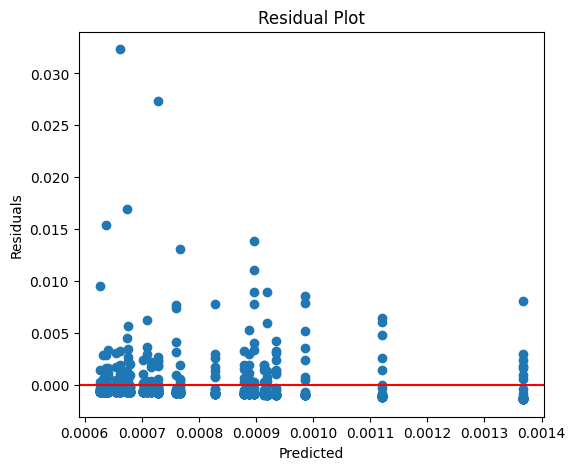

In [99]:
plt.figure(figsize=(6,5))
plt.scatter(predictions_2A, residuals_2A)
plt.axhline(0,color="red")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

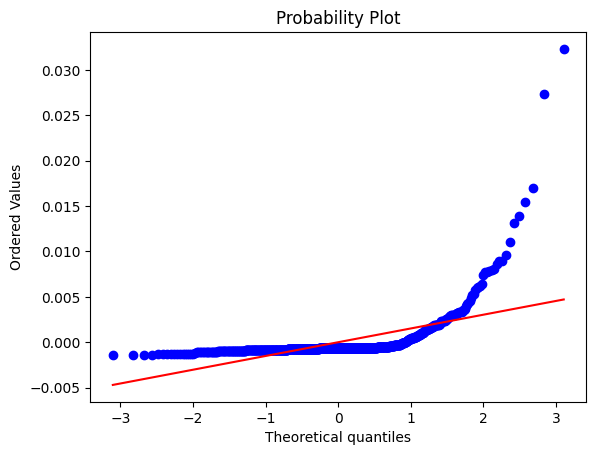

In [100]:
stats.probplot(residuals_2A, dist="norm", plot=plt)

plt.show()

This QQ plot doesnt fit the line too well

### Interpretations

P value of GDP per Capita > 0.05 

P value of Unemployment > 0.05 

- R Squared: 0.004636729590890676

- Adjusted R Squared: 0.0018946820140061105

- F-statistic: 1.6909734280244413

- Model p-value: 0.18506520407179067

- RMSE: 0.002488443222686725

- MAE: 0.001181142450087171

This model explains roughly 0.5% of variance in Log Signatures Per Capita

The model performs poorly and is insignificant as the p value is > 0.05

GDP per Capita and Unemployment poorly explain variance in log signatures per capita in this model

And due to the p value of the model > 0.05 it fails to reject H0 of Research Question 2



### Export

In [101]:
joblib.dump(
    log_model_2A,
    rf"{model_path}/log_regressions/log_regression_model_2a.pkl"
)

['C:/Users/Matty/Documents/College Notes & Assignments/Year 5/Dissertation/MSc-Dissertation/models/log_regressions/log_regression_model_2a.pkl']

## Model 2B

GDP Per Capita + Unemployment + Tertiary Enrollment + Life Expectancy + Population Density vs Log Signatures Per Capita

In [102]:
X = master[
    [
        "GDP_Per_Capita",
        "Unemployment",
        "Tertiary_Enrollment",
        "Life_Expectancy",
        "Population_Density"
    ]
]

y = master["Log_Signatures_Per_Capita"]

### Checking Correlations

In [103]:
X.corr(method="spearman")

,GDP_Per_Capita,Unemployment,Tertiary_Enrollment,Life_Expectancy,Population_Density
GDP_Per_Capita,1.000000,0.007022,0.217338,0.773790,0.300366
Unemployment,0.007022,1.000000,0.282705,0.313627,-0.361166
Tertiary_Enrollment,0.217338,0.282705,1.000000,0.113945,-0.298535
Life_Expectancy,0.773790,0.313627,0.113945,1.000000,0.295708
Population_Density,0.300366,-0.361166,-0.298535,0.295708,1.000000


GDP Per Capita and Life Expectancy share the highest correlations with one another and among other variables

### VIF test on variables

VIF to check variables for multicolinearity

In [104]:
X_vif = sm.add_constant(X)

vif = pd.DataFrame()

vif["Variable"] = X_vif.columns

vif["VIF"] = [
    variance_inflation_factor(
        X_vif.values,
        i
    )
    for i in range(X_vif.shape[1])
]

print(vif)

              Variable          VIF
0                const  1969.790541
1       GDP_Per_Capita     2.123164
2         Unemployment     1.862834
3  Tertiary_Enrollment     1.608670
4      Life_Expectancy     2.666884
5   Population_Density     1.385294


GDP per Capita and Life Expectancy have high VIF values Suggesting Multicolinearity

### Fitting the Model

In [105]:
X = sm.add_constant(X)

log_model_2B = sm.OLS(y, X).fit()

print(log_model_2B.summary())

                                OLS Regression Results                               
Dep. Variable:     Log_Signatures_Per_Capita   R-squared:                       0.007
Model:                                   OLS   Adj. R-squared:                 -0.000
Method:                        Least Squares   F-statistic:                    0.9962
Date:                       Sat, 15 Aug 2026   Prob (F-statistic):              0.419
Time:                               19:25:09   Log-Likelihood:                 3337.6
No. Observations:                        729   AIC:                            -6663.
Df Residuals:                            723   BIC:                            -6636.
Df Model:                                  5                                         
Covariance Type:                   nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------

### Log Linear Regression Model 2B - Evaluation

In [106]:
print("R Squared:", log_model_2B.rsquared)
print("Adjusted R Squared:", log_model_2B.rsquared_adj)
print("F-statistic:", log_model_2B.fvalue)
print("Model p-value:", log_model_2B.f_pvalue)

R Squared: 0.006842129299557187
Adjusted R Squared: -2.6182392700357937e-05
F-statistic: 0.9961879434315946
Model p-value: 0.41904373569367603


### Predictions

In [107]:
predictions_2B = log_model_2B.predict(X)

### RMSE

In [108]:
rmse = np.sqrt(
    mean_squared_error(y, predictions_2B)
)

print(rmse)

0.0024856849054952935


### MAE

In [109]:
mae = mean_absolute_error(
    y,
    predictions_2B
)

print(mae)

0.0011820942763795283


### Residual Plots

In [110]:
residuals_2B = y - predictions_2B

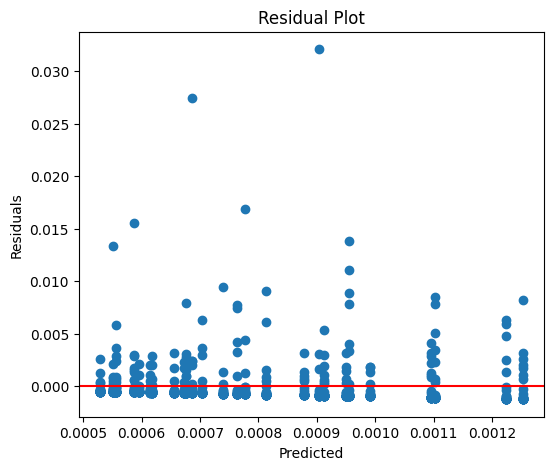

In [111]:
plt.figure(figsize=(6,5))
plt.scatter(predictions_2B, residuals_2B)
plt.axhline(0,color="red")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

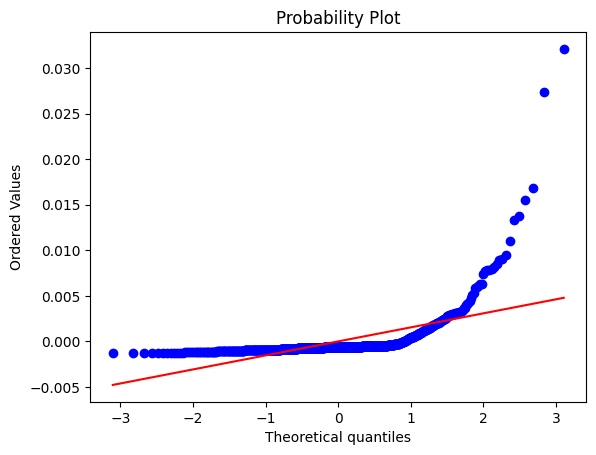

In [112]:
stats.probplot(residuals_2B, dist="norm", plot=plt)

plt.show()

This QQ plot doesnt fit the line too well

### Interpretations

P Value of GDP_Per_Capita > 0.05

P Value of Unemployment > 0.05

P Value of Tertiary_Enrollment > 0.05

P Value of Life_Expectancy > 0.05

P Value of Population_Density > 0.05

- R Squared: 0.006842129299557187

- Adjusted R Squared: -2.6182392700357937e-05

- F-statistic: 0.9961879434315946

- Model p-value: 0.41904373569367603

- RMSE: 0.0024856849054952935

- MAE: 0.0011820942763795283

This model explains roughly 0.68% of variance in Log Signatures Per Capita

The model performs poorly and is insignificant as the p value is > 0.05

R squared adjusted is way off

GDP per Capita, Unemployment Tertiary Enrollment, LIfe Expectancy and Population Density poorly explain variance in Log Signatures Per Capita in this model

And due to the p value of the model > 0.05 it fails to reject H0 of Research Question 2




### Export

In [113]:
joblib.dump(
    log_model_2B,
    rf"{model_path}/log_regressions/log_regression_model_2b.pkl"
)

['C:/Users/Matty/Documents/College Notes & Assignments/Year 5/Dissertation/MSc-Dissertation/models/log_regressions/log_regression_model_2b.pkl']

## Model 2C

Media Literacy Index + Governance + Social Capital + Personal Freedom + Education vs Log Signatures Per Capita

In [114]:
X = master[
    [
        "Media_Literacy_Index",
        "Governance",
        "Social_Capital",
        "Personal_Freedom",
        "Education"
    ]
]

y = master["Log_Signatures_Per_Capita"]

### Checking Correlations

In [115]:
X.corr(method="spearman")

,Media_Literacy_Index,Governance,Social_Capital,Personal_Freedom,Education
Media_Literacy_Index,1.000000,0.860679,0.734189,0.871200,0.860046
Governance,0.860679,1.000000,0.763736,0.961380,0.830408
Social_Capital,0.734189,0.763736,1.000000,0.775149,0.622500
Personal_Freedom,0.871200,0.961380,0.775149,1.000000,0.777405
Education,0.860046,0.830408,0.622500,0.777405,1.000000


Media Literacy Index, Governance, Social Capital, Personal Freedom and Education are all strongly correlated with one another

### VIF test on variables

VIF to check variables for multicolinearity

In [116]:
X_vif = sm.add_constant(X)

vif = pd.DataFrame()

vif["Variable"] = X_vif.columns

vif["VIF"] = [
    variance_inflation_factor(
        X_vif.values,
        i
    )
    for i in range(X_vif.shape[1])
]

print(vif)

               Variable          VIF
0                 const  1419.727030
1  Media_Literacy_Index     5.287755
2            Governance    15.308980
3        Social_Capital     2.452434
4      Personal_Freedom    11.777940
5             Education     4.625809


High VIF values with Personal Freedom, Education, Media Literacy, Governance, Social Capital

There is strong Multicolinearity between each variable

### Fitting the Model

In [117]:
X = sm.add_constant(X)

log_model_2C = sm.OLS(y, X).fit()

print(log_model_2C.summary())

                                OLS Regression Results                               
Dep. Variable:     Log_Signatures_Per_Capita   R-squared:                       0.008
Model:                                   OLS   Adj. R-squared:                  0.001
Method:                        Least Squares   F-statistic:                     1.168
Date:                       Sat, 15 Aug 2026   Prob (F-statistic):              0.323
Time:                               19:25:09   Log-Likelihood:                 3338.0
No. Observations:                        729   AIC:                            -6664.
Df Residuals:                            723   BIC:                            -6636.
Df Model:                                  5                                         
Covariance Type:                   nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------

### Log Linear Regression Model 2C - Evaluation

In [118]:
print("R Squared:", log_model_2C.rsquared)
print("Adjusted R Squared:", log_model_2C.rsquared_adj)
print("F-statistic:", log_model_2C.fvalue)
print("Model p-value:", log_model_2C.f_pvalue)

R Squared: 0.00801376042212043
Adjusted R Squared: 0.0011535512964089278
F-statistic: 1.1681510396068742
Model p-value: 0.32318065080434116


### Predictions

In [119]:
predictions_2C = log_model_2C.predict(X)

### RMSE

In [120]:
rmse = np.sqrt(
    mean_squared_error(y, predictions_2C)
)

print(rmse)

0.002484218288100951


### MAE

In [121]:
mae = mean_absolute_error(
    y,
    predictions_2C
)

print(mae)

0.0011824412993735683


### Residual Plots

In [122]:
residuals_2C = y - predictions_2C

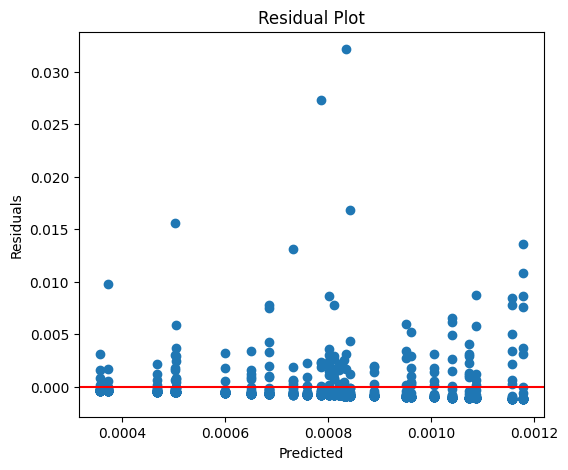

In [123]:
plt.figure(figsize=(6,5))
plt.scatter(predictions_2C, residuals_2C)
plt.axhline(0,color="red")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

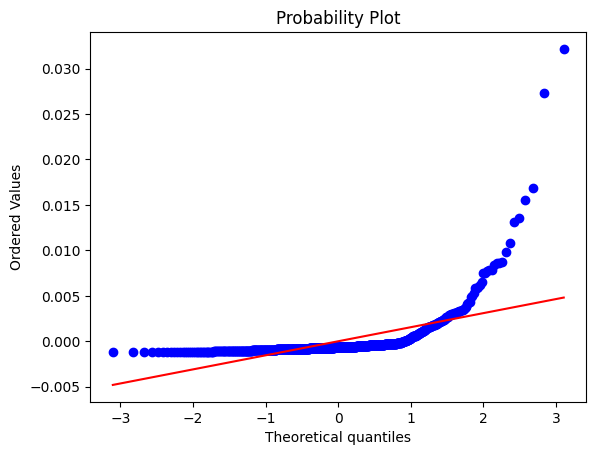

In [124]:
stats.probplot(residuals_2C, dist="norm", plot=plt)

plt.show()

QQ Plot is way off

### Interpretations

P Value of Media Literacy Index > 0.05

P Value of Governance > 0.05

P Value of Social Capital > 0.05

P Value of Personal Freedom > 0.05

P Value of Education > 0.05

- R Squared: 0.00801376042212043

- Adjusted R Squared: 0.0011535512964089278

- F-statistic: 1.1681510396068742

- Model p-value: 0.32318065080434116

- RMSE: 0.002484218288100951

- MAE: 0.0011824412993735683

This model explains roughly 0.80% of variance in Log Signatures Per Capita

The model performs poorly and is insignificant as the p value is > 0.05

Media Literacy Index, Governance, Social Capital, Personal Freedom and Education poorly explain variance in log signatures per capita in this model

And due to the p value of the model > 0.05 it fails to reject H0 of Research Question 2

### Export

In [125]:
joblib.dump(
    log_model_2C,
    rf"{model_path}/log_regressions/log_regression_model_2c.pkl"
)

['C:/Users/Matty/Documents/College Notes & Assignments/Year 5/Dissertation/MSc-Dissertation/models/log_regressions/log_regression_model_2c.pkl']

## Log Linear Regressions 3: Signatures Per Capita (Successful ECI Petitions only)

Can socio-economic indicators explain participation rates when the analysis is reduced to only successful Petitions?

#### Hypotheses: 

H0

Socio-economic indicators have no significant relationship with participation rates when participation is normalised by population

H1

Socio-economic indicators have a limited explanatory power when participation is normalised by population

## Model 3A

GDP Per Capita + Unemployment vs Log Signatures Per Capita

In [126]:
X = successful_master[
    [
        "GDP_Per_Capita",
        "Unemployment"
    ]
]

y = successful_master["Log_Signatures_Per_Capita"]

### Checking Correlations

In [127]:
X.corr(method="spearman")

,GDP_Per_Capita,Unemployment
GDP_Per_Capita,1.000000,0.007022
Unemployment,0.007022,1.000000


low correlation between GDP Per Capita and Unemployment

### VIF test on variables

VIF to check variables for multicolinearity

In [128]:
X_vif = sm.add_constant(X)

vif = pd.DataFrame()

vif["Variable"] = X_vif.columns

vif["VIF"] = [
    variance_inflation_factor(
        X_vif.values,
        i
    )
    for i in range(X_vif.shape[1])
]

print(vif)

         Variable       VIF
0           const  7.631218
1  GDP_Per_Capita  1.010885
2    Unemployment  1.010885


very low VIF values meaning little to no Multicolinearity

### Fitting the Model

In [129]:
X = sm.add_constant(X)

log_model_3A = sm.OLS(y, X).fit()

print(log_model_3A.summary())

                                OLS Regression Results                               
Dep. Variable:     Log_Signatures_Per_Capita   R-squared:                       0.056
Model:                                   OLS   Adj. R-squared:                  0.038
Method:                        Least Squares   F-statistic:                     3.111
Date:                       Sat, 15 Aug 2026   Prob (F-statistic):             0.0487
Time:                               19:25:10   Log-Likelihood:                -144.73
No. Observations:                        108   AIC:                             295.5
Df Residuals:                            105   BIC:                             303.5
Df Model:                                  2                                         
Covariance Type:                   nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------

### Log Linear Regression Model 3A - Evaluation

In [130]:
print("R Squared:", log_model_3A.rsquared)
print("Adjusted R Squared:", log_model_3A.rsquared_adj)
print("F-statistic:", log_model_3A.fvalue)
print("Model p-value:", log_model_3A.f_pvalue)

R Squared: 0.055950103382827576
Adjusted R Squared: 0.03796820059011963
F-statistic: 3.1114673473552696
Model p-value: 0.0486670277477942


### Predictions

In [131]:
predictions_3A = log_model_3A.predict(X)

### RMSE

In [132]:
rmse = np.sqrt(
    mean_squared_error(y, predictions_3A)
)

print(rmse)

0.9241805447928136


### MAE

In [133]:
mae = mean_absolute_error(
    y,
    predictions_3A
)

print(mae)

0.7012100411569654


### Residual Plots

In [134]:
residuals_3A = y - predictions_3A

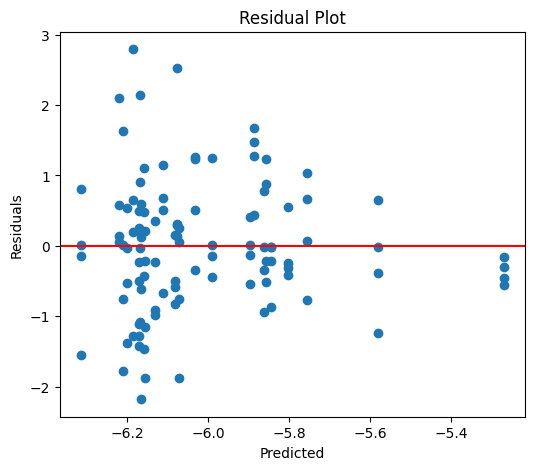

In [135]:
plt.figure(figsize=(6,5))
plt.scatter(predictions_3A, residuals_3A)
plt.axhline(0,color="red")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

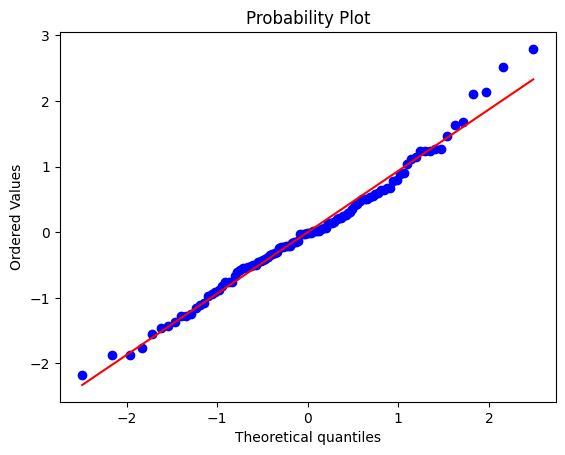

In [136]:
stats.probplot(residuals_3A, dist="norm", plot=plt)

plt.show()

This QQ plot more closely fits the line 

### Interpretations

P value of GDP per Capita < 0.05 

P value of Unemployment > 0.05 

- R Squared: 0.055950103382827576

- Adjusted R Squared: 0.03796820059011963

- F-statistic: 3.1114673473552696

- Model p-value: 0.0486670277477942

- RMSE: 0.9241805447928136

- MAE: 0.7012100411569654

This model explains roughly 5.6% of variance in Log Signatures Per Capita

R squared adjusted isnt too far from R Squared

The model performs moderately well and is significant as the p value is < 0.05

GDP per Capita and Unemployment somewhat explain variance in log signatures per capita in this model

And due to the p value of the model < 0.05 it it rejects th null hypothesis H0 of Research Question 3

However I think I can still do better




### Export

In [137]:
joblib.dump(
    log_model_3A,
    rf"{model_path}/log_regressions/log_regression_model_3a.pkl"
)

['C:/Users/Matty/Documents/College Notes & Assignments/Year 5/Dissertation/MSc-Dissertation/models/log_regressions/log_regression_model_3a.pkl']

## Model 3B

GDP Per Capita + Unemployment + Tertiary Enrollment + Life Expectancy + Population Density vs Log Signatures Per Capita

In [138]:
X = successful_master[
    [
        "GDP_Per_Capita",
        "Unemployment",
        "Tertiary_Enrollment",
        "Life_Expectancy",
        "Population_Density"
    ]
]

y = successful_master["Log_Signatures_Per_Capita"]

### Checking Correlations

In [139]:
X.corr(method="spearman")

,GDP_Per_Capita,Unemployment,Tertiary_Enrollment,Life_Expectancy,Population_Density
GDP_Per_Capita,1.000000,0.007022,0.217338,0.773790,0.300366
Unemployment,0.007022,1.000000,0.282705,0.313627,-0.361166
Tertiary_Enrollment,0.217338,0.282705,1.000000,0.113945,-0.298535
Life_Expectancy,0.773790,0.313627,0.113945,1.000000,0.295708
Population_Density,0.300366,-0.361166,-0.298535,0.295708,1.000000


GDP Per Capita and Life Expectancy share the highest correlations with one another and among other variables

### VIF test on variables

VIF to check variables for multicolinearity

In [140]:
X_vif = sm.add_constant(X)

vif = pd.DataFrame()

vif["Variable"] = X_vif.columns

vif["VIF"] = [
    variance_inflation_factor(
        X_vif.values,
        i
    )
    for i in range(X_vif.shape[1])
]

print(vif)

              Variable          VIF
0                const  1969.790541
1       GDP_Per_Capita     2.123164
2         Unemployment     1.862834
3  Tertiary_Enrollment     1.608670
4      Life_Expectancy     2.666884
5   Population_Density     1.385294


GDP per Capita and Life Expectancy have high VIF values Suggesting Multicolinearity

### Fitting the Model

In [141]:
X = sm.add_constant(X)

log_model_3B = sm.OLS(y, X).fit()

print(log_model_3B.summary())

                                OLS Regression Results                               
Dep. Variable:     Log_Signatures_Per_Capita   R-squared:                       0.079
Model:                                   OLS   Adj. R-squared:                  0.034
Method:                        Least Squares   F-statistic:                     1.746
Date:                       Sat, 15 Aug 2026   Prob (F-statistic):              0.131
Time:                               19:25:10   Log-Likelihood:                -143.40
No. Observations:                        108   AIC:                             298.8
Df Residuals:                            102   BIC:                             314.9
Df Model:                                  5                                         
Covariance Type:                   nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------

### Log Linear Regression Model 3B - Evaluation

In [142]:
print("R Squared:", log_model_3B.rsquared)
print("Adjusted R Squared:", log_model_3B.rsquared_adj)
print("F-statistic:", log_model_3B.fvalue)
print("Model p-value:", log_model_3B.f_pvalue)

R Squared: 0.07884092051628089
Adjusted R Squared: 0.033686063678843636
F-statistic: 1.7460119694348162
Model p-value: 0.130835016837693


### Predictions

In [143]:
predictions_3B = log_model_3B.predict(X)

### RMSE

In [144]:
rmse = np.sqrt(
    mean_squared_error(y, predictions_3B)
)

print(rmse)

0.912907270503988


### MAE

In [145]:
mae = mean_absolute_error(
    y,
    predictions_3B
)

print(mae)

0.6952524568277251


### Residual Plots

In [146]:
residuals_3B = y - predictions_3B

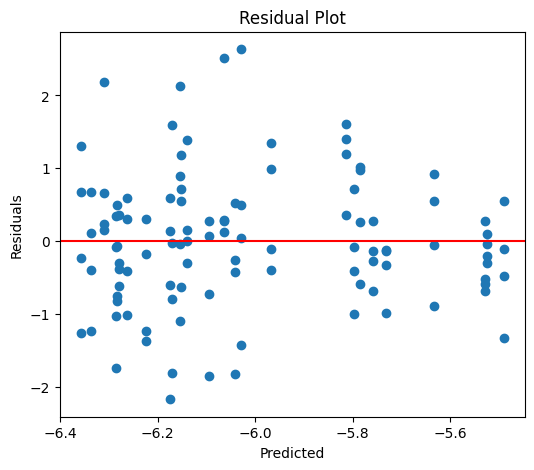

In [147]:
plt.figure(figsize=(6,5))
plt.scatter(predictions_3B, residuals_3B)
plt.axhline(0,color="red")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

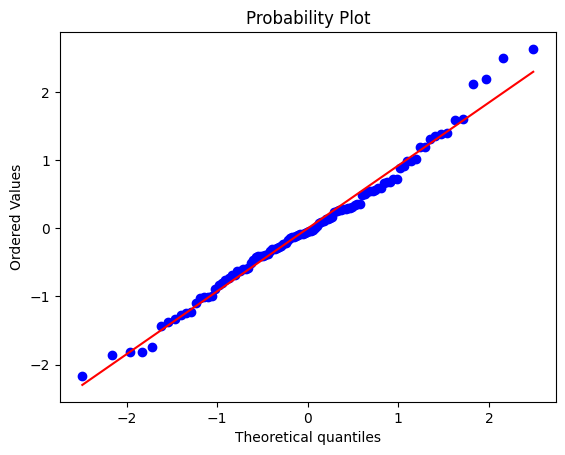

In [148]:
stats.probplot(residuals_3B, dist="norm", plot=plt)

plt.show()

This QQ plot also fits the line pretty well

### Interpretations

P Value of GDP_Per_Capita < 0.05

P Value of Unemployment > 0.05

P Value of Tertiary_Enrollment > 0.05

P Value of Life_Expectancy > 0.05

P Value of Population_Density > 0.05

- R Squared: 0.07884092051628089

- Adjusted R Squared: 0.033686063678843636

- F-statistic: 1.7460119694348162

- Model p-value: 0.130835016837693

- RMSE: 0.912907270503988

- MAE: 0.6952524568277251

This model explains roughly 7.88% of variance in Log Signatures Per Capita

The model performs poorly and is insignificant as the p value is > 0.05

GDP per Capita, Unemployment, Tertiary Enrollment, Life Expectancy and Population Density poorly explain variance in Log Signatures Per Capita in this model

And due to the p value of the model > 0.05 it fails to reject H0 of Research Question 3


### Export

In [149]:
joblib.dump(
    log_model_3B,
    rf"{model_path}/log_regressions/log_regression_model_3b.pkl"
)

['C:/Users/Matty/Documents/College Notes & Assignments/Year 5/Dissertation/MSc-Dissertation/models/log_regressions/log_regression_model_3b.pkl']

## Model 3C

Media Literacy Index + Governance + Social Capital + Personal Freedom + Education vs Log Signatures Per Capita

In [150]:
X = successful_master[
    [
        "Media_Literacy_Index",
        "Governance",
        "Social_Capital",
        "Personal_Freedom",
        "Education"
    ]
]

y = successful_master["Log_Signatures_Per_Capita"]

### Checking Correlations

In [151]:
X.corr(method="spearman")

,Media_Literacy_Index,Governance,Social_Capital,Personal_Freedom,Education
Media_Literacy_Index,1.000000,0.860679,0.734189,0.871200,0.860046
Governance,0.860679,1.000000,0.763736,0.961380,0.830408
Social_Capital,0.734189,0.763736,1.000000,0.775149,0.622500
Personal_Freedom,0.871200,0.961380,0.775149,1.000000,0.777405
Education,0.860046,0.830408,0.622500,0.777405,1.000000


Media Literacy Index, Governance, Social Capital, Personal Freedom and Education are all strongly correlated with one another

### VIF test on variables

VIF to check variables for multicolinearity

In [152]:
X_vif = sm.add_constant(X)

vif = pd.DataFrame()

vif["Variable"] = X_vif.columns

vif["VIF"] = [
    variance_inflation_factor(
        X_vif.values,
        i
    )
    for i in range(X_vif.shape[1])
]

print(vif)

               Variable          VIF
0                 const  1419.727030
1  Media_Literacy_Index     5.287755
2            Governance    15.308980
3        Social_Capital     2.452434
4      Personal_Freedom    11.777940
5             Education     4.625809


High VIF values with Personal Freedom, Education, Media Literacy, Governance, Social Capital

There is strong Multicolinearity between each variable

### Fitting the Model

In [153]:
X = sm.add_constant(X)

log_model_3C = sm.OLS(y, X).fit()

print(log_model_3C.summary())

                                OLS Regression Results                               
Dep. Variable:     Log_Signatures_Per_Capita   R-squared:                       0.119
Model:                                   OLS   Adj. R-squared:                  0.075
Method:                        Least Squares   F-statistic:                     2.747
Date:                       Sat, 15 Aug 2026   Prob (F-statistic):             0.0227
Time:                               19:25:11   Log-Likelihood:                -141.02
No. Observations:                        108   AIC:                             294.0
Df Residuals:                            102   BIC:                             310.1
Df Model:                                  5                                         
Covariance Type:                   nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------

### Log Linear Regression Model 3C - Evaluation

In [154]:
print("R Squared:", log_model_3C.rsquared)
print("Adjusted R Squared:", log_model_3C.rsquared_adj)
print("F-statistic:", log_model_3C.fvalue)
print("Model p-value:", log_model_3C.f_pvalue)

R Squared: 0.11865974293610237
Adjusted R Squared: 0.07545678915846032
F-statistic: 2.746565513710546
Model p-value: 0.022729910301383778


### Predictions

In [155]:
predictions_3C = log_model_3C.predict(X)

### RMSE

In [156]:
rmse = np.sqrt(
    mean_squared_error(y, predictions_3C)
)

print(rmse)

0.8929582442345007


### MAE

In [157]:
mae = mean_absolute_error(
    y,
    predictions_3C
)

print(mae)

0.6824525781448116


### Residual Plots

In [158]:
residuals_3C = y - predictions_3C

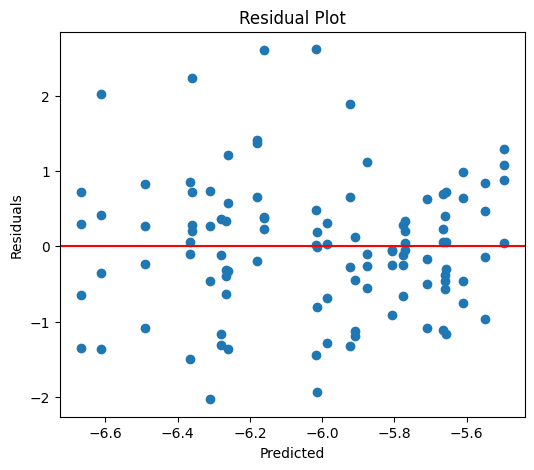

In [159]:
plt.figure(figsize=(6,5))
plt.scatter(predictions_3C, residuals_3C)
plt.axhline(0,color="red")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

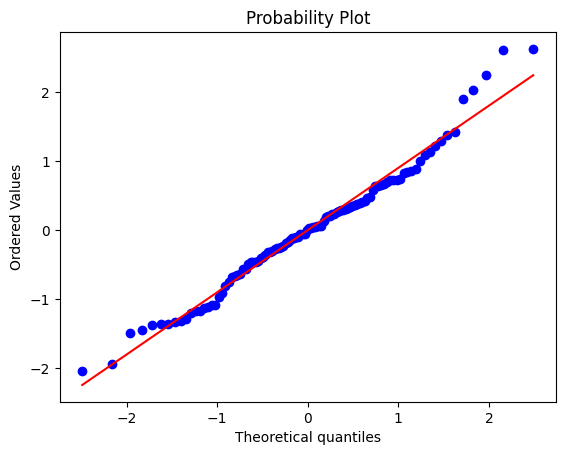

In [160]:
stats.probplot(residuals_3C, dist="norm", plot=plt)

plt.show()

This QQ plot fits the line pretty well

### Interpretations

P Value of Media Literacy Index > 0.05

P Value of Governance > 0.05

P Value of Social Capital > 0.05

P Value of Personal Freedom > 0.05

P Value of Education > 0.05

- R Squared: 0.11865974293610237

- Adjusted R Squared: 0.07545678915846032

- F-statistic: 2.746565513710546

- Model p-value: 0.022729910301383778

- RMSE: 0.8929582442345007

- MAE: 0.6824525781448116

This model explains roughly 11.87% of variance in Log Signatures Per Capita

The model performs quite well and is significant as the p value is < 0.05

Media Literacy Index, Governance, Social Capital, Personal Freedom and Education explain variance pretty well somewhat in log signatures per capita in this model

And due to the p value of the model < 0.05 it rejects the null hypothesis H0 of Research Question 3

### Export

In [161]:
joblib.dump(
    log_model_3C,
    rf"{model_path}/log_regressions/log_regression_model_3c.pkl"
)

['C:/Users/Matty/Documents/College Notes & Assignments/Year 5/Dissertation/MSc-Dissertation/models/log_regressions/log_regression_model_3c.pkl']

### Log Linear Regressions Evaluation

The models for Question 2 fail to prove that country level variables explain a significant amount of variance in Log Signatures per Capita

Currently failed to reject Null hypothesis

The models for Question 3 prove that country level variables explain a significant amount of variance in Log Signatures per Capita

Currently Models 3A and 3C reject the Null hypothesis

Model 3C shows the most promise with roughly 12% explained variance in the model using the newly added variables comboned with the log transformed Signatures Per Capita on the Successful Petitions Dataset

This shows somewhat that variability is too great among non successful models creating too much noise for the model to adequately predict signatures per capita

The dataset that is restricted to successful petitions is much more predictable, and the log transformed Signatures Per Capita works a lot better with the variables in each model

I will continue to develop more models such as PCA regressions and Random Forest Regressions to further explore question 2 and 3